# auth.md → 선택적 skills.md 접근 → Tool Layer 실험

## 아키텍처

```
사용자
  ↓
auth.md (단일 권한 소스)
  ├── skill:* 스코프 → skills.md 접근 게이팅 (Layer 1)
  └── read:*/write:* 스코프 → 스킬 내부 Tool 실행 게이팅 (Layer 2)
  ↓
선택적 skills.md 접근 (Layer 1 통과한 스킬만 로드)
  ↓
Skill Layer (복합 워크플로우 실행)
  ↓
Tool Layer (원자적 API/DB 접근)
```

## 이전 실험(`run.ipynb`)과의 차이

| 항목 | Tool 실험 | 이 실험 |
|------|-----------|---------|
| 권한 소스 | auth.md | auth.md (동일) |
| 제어 레이어 | 1개 (tool 레벨) | **2개** (skill 레벨 + tool 레벨) |
| skills.md 역할 | 없음 | auth.md 스코프로 게이팅되는 레지스트리 |
| 부분 실패 케이스 | 없음 | skill 접근은 가능하나 내부 tool 권한 부족 시 |

## 핵심 실험 케이스
`skill:reporting` 스코프는 있지만 `write:external`이 없는 사용자 —
skills.md 접근은 허용되지만 스킬 실행 중 Tool Layer에서 차단됨.

In [20]:
import os
import re
import yaml
from functools import wraps
from typing import Any
from dataclasses import dataclass, field
from collections import defaultdict
from dotenv import load_dotenv
from langchain_core.tools import tool, StructuredTool
from deepagents import create_deep_agent
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

load_dotenv()

MODEL = "anthropic:claude-haiku-4-5-20251001"
print(f"모델: {MODEL}")
print("deepagents + LangChain v1.0+ 준비 완료")

모델: anthropic:claude-haiku-4-5-20251001
deepagents + LangChain v1.0+ 준비 완료


## Part 1: auth.md — 단일 권한 소스

auth.md는 **두 종류의 스코프**를 모두 정의한다:
- `skill:*` 스코프 → skills.md 접근 게이팅 (Layer 1)
- `read:*` / `write:*` 스코프 → 스킬 내부 Tool 실행 게이팅 (Layer 2)

사용자가 `skill:reporting`을 가져도 `write:external`이 없으면
→ skills.md에서 reporting_skill을 로드하지만 → Tool Layer에서 차단된다.

In [21]:
def parse_auth_md(content: str) -> dict:
    match = re.match(r"^---\n(.*?)\n---", content, re.DOTALL)
    if not match:
        raise ValueError("auth.md에 YAML frontmatter가 없습니다.")
    return yaml.safe_load(match.group(1))


AUTH_MD_CONTENT = """
---
version: "1.0"
service: "research-platform.internal"
auth_endpoint: "https://research-platform.internal/agent/auth"

scopes:
  # ── Layer 1: skills.md 접근 게이팅 스코프 ─────────────────
  skill:research:      "research_skill 실행 권한 (skills.md 접근)"
  skill:data_analysis: "data_analysis_skill 실행 권한 (skills.md 접근)"
  skill:notification:  "notification_skill 실행 권한 (skills.md 접근)"
  skill:reporting:     "reporting_skill 실행 권한 (skills.md 접근)"
  skill:code_review:   "code_review_skill 실행 권한 (skills.md 접근)"

  # ── Layer 2: Tool 실행 게이팅 스코프 (스킬 내부에서 사용) ──
  read:internal:  "내부 DB/파일 조회 (Tool Layer)"
  write:internal: "내부 DB 쓰기 (Tool Layer)"
  read:external:  "외부 API/웹 검색 (Tool Layer)"
  write:external: "알림 발송 (Tool Layer)"
  admin:all:      "시스템 관리 (Tool Layer)"

roles:
  admin:
    - skill:research
    - skill:data_analysis
    - skill:notification
    - skill:reporting
    - skill:code_review
    - read:internal
    - write:internal
    - read:external
    - write:external
    - admin:all

  analyst:
    - skill:research
    - skill:data_analysis
    - skill:reporting
    - read:internal       # data_analysis + reporting 내부 tool 실행 가능
    - read:external

  # skill 스코프는 있지만 일부 tool 스코프가 없음 → Layer 2에서 부분 차단
  analyst_restricted:
    - skill:research
    - skill:data_analysis
    - skill:reporting
    - read:external
    # read:internal 없음 → data_analysis 내부 DB 조회 실패

  developer:
    - skill:research
    - skill:notification
    - skill:code_review
    - read:internal
    - read:external
    - write:external

  viewer:
    - skill:research
    - read:external       # research_skill 내부 tool만 사용 가능

  guest: []
---
"""

AUTH_MD = parse_auth_md(AUTH_MD_CONTENT.strip())

print("서비스:", AUTH_MD["service"])
print("\n스코프 분류:")
for s, d in AUTH_MD["scopes"].items():
    layer = "Layer 1 (skill 게이팅)" if s.startswith("skill:") else "Layer 2 (tool 게이팅)"
    print(f"  {s:22s} | {layer:26s} | {d}")
print("\n역할별 권한:")
for role, scopes in AUTH_MD["roles"].items():
    print(f"  {role:20s} | {sorted(scopes)}")

서비스: research-platform.internal

스코프 분류:
  skill:research         | Layer 1 (skill 게이팅)        | research_skill 실행 권한 (skills.md 접근)
  skill:data_analysis    | Layer 1 (skill 게이팅)        | data_analysis_skill 실행 권한 (skills.md 접근)
  skill:notification     | Layer 1 (skill 게이팅)        | notification_skill 실행 권한 (skills.md 접근)
  skill:reporting        | Layer 1 (skill 게이팅)        | reporting_skill 실행 권한 (skills.md 접근)
  skill:code_review      | Layer 1 (skill 게이팅)        | code_review_skill 실행 권한 (skills.md 접근)
  read:internal          | Layer 2 (tool 게이팅)         | 내부 DB/파일 조회 (Tool Layer)
  write:internal         | Layer 2 (tool 게이팅)         | 내부 DB 쓰기 (Tool Layer)
  read:external          | Layer 2 (tool 게이팅)         | 외부 API/웹 검색 (Tool Layer)
  write:external         | Layer 2 (tool 게이팅)         | 알림 발송 (Tool Layer)
  admin:all              | Layer 2 (tool 게이팅)         | 시스템 관리 (Tool Layer)

역할별 권한:
  admin                | ['admin:all', 'read:external', 'read:internal', 'skill:code_r

In [22]:
class AuthContext:
    """
    auth.md 기반 단일 권한 컨텍스트.
    skill 레벨 + tool 레벨 스코프를 모두 관리한다.
    """
    def __init__(self, user_id: str, role: str, auth_md: dict | None = None):
        self.user_id = user_id
        self.role = role
        _md = auth_md or AUTH_MD
        self.scopes: set[str] = set(_md["roles"].get(role, []))

    def can_access_skill(self, skill_scope: str) -> bool:
        """Layer 1: skills.md 접근 여부 — skill:* 스코프 확인."""
        return skill_scope in self.scopes

    def can_use_tool(self, tool_scope: str) -> bool:
        """Layer 2: Tool 실행 여부 — read:*/write:* 스코프 확인."""
        return tool_scope in self.scopes

    def upgrade_scope(self, new_scope: str, reason: str = "OTP claim confirmed"):
        if new_scope in AUTH_MD["scopes"]:
            self.scopes.add(new_scope)
            print(f"[AuthContext] scope 업그레이드: '{new_scope}' ({reason})")
            print(f"[AuthContext] 현재 scopes: {sorted(self.scopes)}")
        else:
            print(f"[AuthContext] 알 수 없는 scope: '{new_scope}'")

    @property
    def skill_scopes(self) -> set[str]:
        return {s for s in self.scopes if s.startswith("skill:")}

    @property
    def tool_scopes(self) -> set[str]:
        return {s for s in self.scopes if not s.startswith("skill:")}

    def __repr__(self):
        return f"AuthContext(user={self.user_id}, role={self.role})"


users = {
    "alice":              AuthContext("alice",              "admin"),
    "diana":              AuthContext("diana",              "analyst"),
    "diana_r":            AuthContext("diana_r",            "analyst_restricted"),
    "bob":                AuthContext("bob",                "developer"),
    "carol":              AuthContext("carol",              "viewer"),
    "guest1":             AuthContext("guest1",             "guest"),
}

print(f"{'사용자':12s} | {'역할':20s} | {'skill 스코프':40s} | tool 스코프")
print("-" * 110)
for name, ctx in users.items():
    print(f"  {name:10s} | {ctx.role:20s} | {sorted(ctx.skill_scopes)} | {sorted(ctx.tool_scopes)}")

사용자          | 역할                   | skill 스코프                                | tool 스코프
--------------------------------------------------------------------------------------------------------------
  alice      | admin                | ['skill:code_review', 'skill:data_analysis', 'skill:notification', 'skill:reporting', 'skill:research'] | ['admin:all', 'read:external', 'read:internal', 'write:external', 'write:internal']
  diana      | analyst              | ['skill:data_analysis', 'skill:reporting', 'skill:research'] | ['read:external', 'read:internal']
  diana_r    | analyst_restricted   | ['skill:data_analysis', 'skill:reporting', 'skill:research'] | ['read:external']
  bob        | developer            | ['skill:code_review', 'skill:notification', 'skill:research'] | ['read:external', 'read:internal', 'write:external']
  carol      | viewer               | ['skill:research'] | ['read:external']
  guest1     | guest                | [] | []


## Part 2: skills.md — auth.md 스코프로 게이팅되는 스킬 레지스트리

skills.md는 **독립적인 권한 시스템이 아니다**.
각 스킬은 auth.md의 `skill:*` 스코프를 게이트키로 사용하고,
내부적으로 어떤 `tool 스코프`(auth.md Layer 2)가 필요한지를 선언한다.

```
skills.md 항목:
  research_skill:
    required_scope: skill:research          ← auth.md Layer 1 게이트키
    internal_tool_scopes: [read:external]   ← auth.md Layer 2 필요 스코프
```

In [23]:
SKILLS_MD_CONTENT = """
---
version: "1.0"
registry: "research-platform.internal/skills"

skills:
  research_skill:
    required_scope: "skill:research"
    description: "웹 리서치 워크플로우: 키워드 추출→검색→수집→요약"
    internal_tool_scopes: ["read:external"]

  data_analysis_skill:
    required_scope: "skill:data_analysis"
    description: "데이터 분석 워크플로우: DB조회→정제→통계→리포트"
    internal_tool_scopes: ["read:internal", "read:external"]

  notification_skill:
    required_scope: "skill:notification"
    description: "알림 발송 워크플로우: 수신자확인→포매팅→발송"
    internal_tool_scopes: ["write:external"]

  reporting_skill:
    required_scope: "skill:reporting"
    description: "통합 리포트 워크플로우: 수집→분석→생성→배포"
    internal_tool_scopes: ["read:internal", "read:external", "write:external"]

  code_review_skill:
    required_scope: "skill:code_review"
    description: "코드 리뷰 워크플로우: 파일로드→파싱→분석→리뷰"
    internal_tool_scopes: ["read:internal"]
---
"""

def parse_skills_md(content: str) -> dict:
    match = re.match(r"^---\n(.*?)\n---", content, re.DOTALL)
    if not match:
        raise ValueError("skills.md에 YAML frontmatter가 없습니다.")
    return yaml.safe_load(match.group(1))

SKILLS_MD = parse_skills_md(SKILLS_MD_CONTENT.strip())

print("스킬 레지스트리:")
print(f"  {'스킬':25s} | {'Layer1 게이트 (auth.md)':25s} | Layer2 필요 tool 스코프")
print("-" * 90)
for name, info in SKILLS_MD["skills"].items():
    print(f"  {name:25s} | {info['required_scope']:25s} | {info['internal_tool_scopes']}")


def get_accessible_skills(auth_ctx: AuthContext) -> dict:
    """
    auth.md 스코프 기반으로 접근 가능한 skills.md 항목을 반환한다.
    Layer 1: skill:* 스코프 확인
    """
    return {
        name: info
        for name, info in SKILLS_MD["skills"].items()
        if auth_ctx.can_access_skill(info["required_scope"])
    }

print("\n역할별 접근 가능한 스킬 (Layer 1 필터):")
for name, ctx in users.items():
    accessible = list(get_accessible_skills(ctx).keys())
    print(f"  {name:12s} | {accessible}")

스킬 레지스트리:
  스킬                        | Layer1 게이트 (auth.md)      | Layer2 필요 tool 스코프
------------------------------------------------------------------------------------------
  research_skill            | skill:research            | ['read:external']
  data_analysis_skill       | skill:data_analysis       | ['read:internal', 'read:external']
  notification_skill        | skill:notification        | ['write:external']
  reporting_skill           | skill:reporting           | ['read:internal', 'read:external', 'write:external']
  code_review_skill         | skill:code_review         | ['read:internal']

역할별 접근 가능한 스킬 (Layer 1 필터):
  alice        | ['research_skill', 'data_analysis_skill', 'notification_skill', 'reporting_skill', 'code_review_skill']
  diana        | ['research_skill', 'data_analysis_skill', 'reporting_skill']
  diana_r      | ['research_skill', 'data_analysis_skill', 'reporting_skill']
  bob          | ['research_skill', 'notification_skill', 'code_review_skill']
  ca

## Part 3: Tool Layer — 원자적 작업 실행

각 tool은 auth.md의 `read:*`/`write:*` 스코프를 필요로 한다.
스킬 내부에서 tool을 호출할 때 **Layer 2 auth 체크**가 적용된다.

In [24]:
# ─── 원자적 Tool 정의 ────────────────────────────────────────
def _query_db(query: str) -> str:
    return f"[DB] '{query}' → {{users: [alice, bob], count: 2}}"

def _write_db(table: str, data: str) -> str:
    return f"[DB Write] {table}: {data} 저장 완료"

def _read_file(path: str) -> str:
    return f"[File] {path}: config_version=2.1, max_conn=100"

def _web_search(query: str) -> str:
    return f"[Search] '{query}' → 문서 5건 발견: docs.example.com..."

def _send_notification(channel: str, message: str) -> str:
    return f"[Notify] {channel} → '{message}' 발송 완료"

# Tool 실행기: auth Layer 2 체크 포함
TOOL_REGISTRY = {
    "read:internal":  {"fn": _query_db,          "args": ["query"],           "desc": "내부 DB 조회"},
    "write:internal": {"fn": _write_db,           "args": ["table", "data"],   "desc": "내부 DB 쓰기"},
    "read:external":  {"fn": _web_search,         "args": ["query"],           "desc": "웹 검색"},
    "write:external": {"fn": _send_notification,  "args": ["channel", "message"],  "desc": "알림 발송"},
}

def execute_tool(scope: str, auth_ctx: AuthContext, **kwargs) -> str:
    """Layer 2: tool 실행 — auth.md tool 스코프 확인 후 실행."""
    if not auth_ctx.can_use_tool(scope):
        return f"[TOOL DENIED] '{scope}' 권한 없음. 현재 tool 스코프: {sorted(auth_ctx.tool_scopes)}"
    return TOOL_REGISTRY[scope]["fn"](**kwargs)

print("Tool Layer 등록:")
for scope, info in TOOL_REGISTRY.items():
    print(f"  {scope:18s} | {info['desc']}")

Tool Layer 등록:
  read:internal      | 내부 DB 조회
  write:internal     | 내부 DB 쓰기
  read:external      | 웹 검색
  write:external     | 알림 발송


## Part 4: Two-Layer Auth Agent 구현

### 전체 흐름
```
create_agent(auth_ctx)
      ↓
[Layer 1] get_accessible_skills(auth_ctx)
  → auth.md skill:* 스코프로 skills.md 필터링
      ↓
필터링된 스킬마다 skill_tool 생성
  → 각 skill_tool 내부에서 execute_tool() 호출
  → [Layer 2] auth.md read:*/write:* 스코프 확인
      ↓
create_deep_agent(model, tools=accessible_skill_tools)
```

### 부분 실패 케이스 (핵심)
`analyst_restricted` 역할:
- Layer 1 통과: `skill:data_analysis` 스코프 보유 → skills.md 접근 허용
- Layer 2 차단: `read:internal` 스코프 없음 → DB 조회 tool 실패
→ 스킬은 로드되지만 실행 중 부분 실패

In [25]:
def build_skill_tool(skill_name: str, skill_info: dict, auth_ctx: AuthContext) -> StructuredTool:
    """
    skills.md 항목 하나를 StructuredTool로 변환한다.
    실행 시 Layer 2 auth 체크(내부 tool 스코프 확인)를 수행한다.
    """
    required_tool_scopes: list[str] = skill_info["internal_tool_scopes"]
    description: str = skill_info["description"]

    def skill_executor(request: str) -> str:
        """사용자 요청을 받아 스킬 워크플로우를 실행한다."""
        steps = []
        denied = []

        # Layer 2: 필요한 tool 스코프 체크 및 실행
        for scope in required_tool_scopes:
            if not auth_ctx.can_use_tool(scope):
                denied.append(scope)
                steps.append(f"  [TOOL DENIED] '{scope}' 권한 없음")
            else:
                # tool 실행 (실제 구현에서는 request 파싱 후 인자 전달)
                result = TOOL_REGISTRY[scope]["fn"](
                    **{arg: request for arg in TOOL_REGISTRY[scope]["args"]}
                )
                steps.append(f"  [OK] {scope}: {result}")

        status = "완료" if not denied else f"부분 실패 (차단된 tool: {denied})"
        return (
            f"[{skill_name}] {status}\n"
            + "\n".join(steps)
        )

    return StructuredTool.from_function(
        func=skill_executor,
        name=skill_name,
        description=description,
    )


def create_two_layer_agent(auth_ctx: AuthContext, verbose: bool = True):
    """
    auth.md 기반 두 레이어 권한 체크 후 agent 생성.
    Layer 1: skills.md 접근 필터링
    Layer 2: 각 skill 내 tool 실행 권한은 실행 시점에 확인
    """
    # Layer 1: auth.md → skills.md 접근 필터
    accessible = get_accessible_skills(auth_ctx)

    if verbose:
        print(f"\n{'='*65}")
        print(f"[Agent] {auth_ctx.user_id:15s} | role: {auth_ctx.role}")
        print(f"[Layer 1] skill 스코프: {sorted(auth_ctx.skill_scopes)}")
        print(f"[Layer 1] 접근 가능 skills ({len(accessible)}/{len(SKILLS_MD['skills'])}개):")
        for name in SKILLS_MD["skills"]:
            mark = "ok" if name in accessible else "--"
            print(f"  {mark}  {name}")
        print(f"[Layer 2] tool  스코프: {sorted(auth_ctx.tool_scopes)}")
        print(f"{'='*65}")

    if not accessible:
        if verbose:
            print("[Agent] 접근 가능한 skill 없음 → agent 생성 불가")
        return None

    # 접근 가능한 스킬만 tool로 빌드
    skill_tools = [
        build_skill_tool(name, info, auth_ctx)
        for name, info in accessible.items()
    ]

    return create_deep_agent(model=MODEL, tools=skill_tools)


def run_test(auth_ctx: AuthContext, query: str, agent=None):
    if agent is None:
        agent = create_two_layer_agent(auth_ctx)
    if agent is None:
        print(f"[결과] {auth_ctx.user_id}: 실행 불가\n")
        return None
    print(f"\n[쿼리] {query}")
    result = agent.invoke({"messages": [{"role": "user", "content": query}]})
    final = result["messages"][-1].content
    print(f"[응답] {final[:400]}{'...' if len(final) > 400 else ''}\n")
    return agent

---
## Experiment 1: 역할별 Two-Layer 권한 분리

각 역할에 대해 Layer 1(skills.md 접근)과 Layer 2(tool 실행) 동작을 확인한다.


EXPERIMENT 1: Two-Layer Auth — 역할별 동작

[Agent] alice           | role: admin
[Layer 1] skill 스코프: ['skill:code_review', 'skill:data_analysis', 'skill:notification', 'skill:reporting', 'skill:research']
[Layer 1] 접근 가능 skills (5/5개):
  ok  research_skill
  ok  data_analysis_skill
  ok  notification_skill
  ok  reporting_skill
  ok  code_review_skill
[Layer 2] tool  스코프: ['admin:all', 'read:external', 'read:internal', 'write:external', 'write:internal']

[쿼리] 이번 달 성과 리포트를 생성하고 팀에게 배포해줘.
[응답] 안녕하세요! 이번 달 성과 리포트를 생성하고 배포하려면 몇 가지 정보가 필요합니다:

1. **성과 데이터 출처**: 어디서 성과 데이터를 가져와야 하나요? (예: 특정 파일, 데이터베이스, 공유 폴더)
2. **리포트 범위**: 어떤 부서/팀의 성과를 포함해야 하나요?
3. **주요 지표**: 리포트에 포함해야 할 주요 성과 지표가 무엇인가요? (예: 매출, 완료된 프로젝트, KPI 등)
4. **배포 대상**: 팀의 이메일 주소나 연락처 정보가 있나요?
5. **리포트 형식**: 선호하는 형식이 있나요? (예: PDF, Excel, PPT)

이 정보들을 알려주시면 성과 리포트를 생성하고 배포해드리겠습니다!



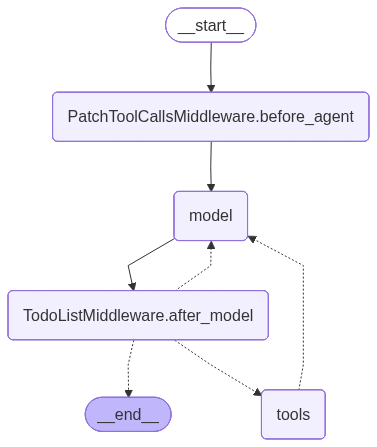

In [26]:
Q_ANALYSIS  = "sales 데이터를 분석하고 결과를 정리해줘."
Q_REPORT    = "이번 달 성과 리포트를 생성하고 팀에게 배포해줘."
Q_RESEARCH  = "LangChain v1.0 변경사항을 리서치해줘."
Q_NOTIFY    = "개발팀에 배포 완료 알림을 Slack으로 보내줘."

print("\n" + "="*65)
print("EXPERIMENT 1: Two-Layer Auth — 역할별 동작")
print("="*65)

# admin: Layer 1 + Layer 2 모두 통과
run_test(users["alice"], Q_REPORT)


[Agent] diana           | role: analyst
[Layer 1] skill 스코프: ['skill:data_analysis', 'skill:reporting', 'skill:research']
[Layer 1] 접근 가능 skills (3/5개):
  ok  research_skill
  ok  data_analysis_skill
  --  notification_skill
  ok  reporting_skill
  --  code_review_skill
[Layer 2] tool  스코프: ['read:external', 'read:internal']

[쿼리] sales 데이터를 분석하고 결과를 정리해줘.
[응답] Sales 데이터 파일을 찾을 수 없습니다. 다음 정보를 확인해주세요:

1. **데이터 파일의 위치** - 어디에 저장되어 있나요? (예: `/home/user/sales.csv`, `/data/sales.xlsx` 등)
2. **데이터 형식** - 파일 형식은 무엇인가요? (CSV, Excel, JSON 등)
3. **분석 범위** - 어떤 항목들을 분석하고 싶으신가요? (매출액, 판매량, 지역별, 상품별, 기간별 등)

파일 경로를 알려주시면 데이터를 분석해드리겠습니다.



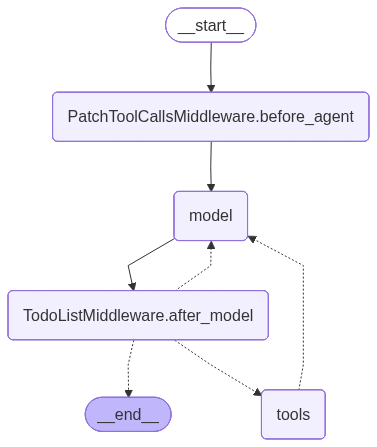

In [27]:
# analyst: Layer 1 통과 (skill:data_analysis, skill:reporting 보유)
# Layer 2 통과 (read:internal, read:external 보유)
run_test(users["diana"], Q_ANALYSIS)


[핵심 케이스] analyst_restricted — skill 접근 O, tool 일부 X

[Agent] diana_r         | role: analyst_restricted
[Layer 1] skill 스코프: ['skill:data_analysis', 'skill:reporting', 'skill:research']
[Layer 1] 접근 가능 skills (3/5개):
  ok  research_skill
  ok  data_analysis_skill
  --  notification_skill
  ok  reporting_skill
  --  code_review_skill
[Layer 2] tool  스코프: ['read:external']

[쿼리] sales 데이터를 분석하고 결과를 정리해줘.
[응답] 시스템에서 sales 데이터 파일을 찾을 수 없습니다. 다음 중 하나를 진행해주면 됩니다:

1. **파일 경로 제공** - sales 데이터 파일의 정확한 경로를 알려주시면 분석하겠습니다
2. **파일 업로드** - CSV, Excel 등의 sales 데이터 파일을 제공해주세요
3. **샘플 데이터 생성** - 샘플 sales 데이터를 생성하여 분석 방법을 보여드릴 수 있습니다

어떤 방식으로 진행하시겠어요?



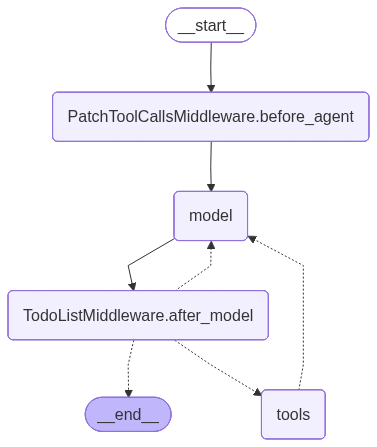

In [28]:
# analyst_restricted: Layer 1 통과 (skill:data_analysis 보유)
# Layer 2 부분 차단 (read:internal 없음 → DB 조회 실패)
# 핵심 케이스: skills.md 접근은 허용되지만 tool 실행에서 부분 실패
print("\n[핵심 케이스] analyst_restricted — skill 접근 O, tool 일부 X")
run_test(users["diana_r"], Q_ANALYSIS)


[Agent] carol           | role: viewer
[Layer 1] skill 스코프: ['skill:research']
[Layer 1] 접근 가능 skills (1/5개):
  ok  research_skill
  --  data_analysis_skill
  --  notification_skill
  --  reporting_skill
  --  code_review_skill
[Layer 2] tool  스코프: ['read:external']

[쿼리] LangChain v1.0 변경사항을 리서치해줘.
[응답] LangChain v1.0의 주요 변경사항을 정리해드렸습니다:

## **주요 Breaking Changes**

1. **LangChain 패키지 분리**
   - `langchain-core` (기본 추상화)
   - `langchain-community` (커뮤니티 통합)
   - `langchain` (고수준 API)
   - 이전에 monolithic 패키지였던 것이 분리됨

2. **Import 경로 변경**
   - 구식: `from langchain import LLM`
   - 신규: `from langchain_openai import ChatOpenAI`
   - 각 LLM 제공자별 독립 패키지로 이동

3. **Chain API 변경**
   - `.run()` 메서드 제거 → `.in...



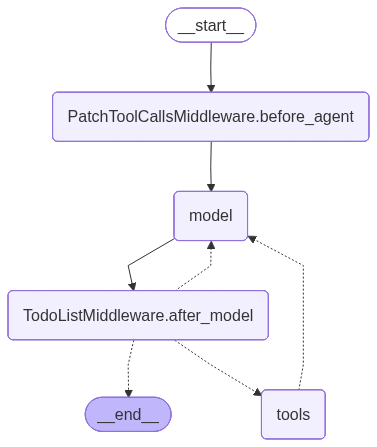

In [29]:
# viewer: Layer 1에서 skill:research만 통과
# Layer 2: read:external만 있음 → research 내부 web_search만 사용 가능
run_test(users["carol"], Q_RESEARCH)

In [30]:
# guest: Layer 1에서 전체 차단
run_test(users["guest1"], Q_RESEARCH)


[Agent] guest1          | role: guest
[Layer 1] skill 스코프: []
[Layer 1] 접근 가능 skills (0/5개):
  --  research_skill
  --  data_analysis_skill
  --  notification_skill
  --  reporting_skill
  --  code_review_skill
[Layer 2] tool  스코프: []
[Agent] 접근 가능한 skill 없음 → agent 생성 불가
[결과] guest1: 실행 불가



---
## Experiment 2: auth.md Scope 업그레이드 (User Claimed 플로우)

`analyst_restricted`가 OTP 인증으로 `read:internal`을 추가 획득하는 시나리오.
Layer 1은 이미 통과했으므로, Layer 2 tool 권한만 업그레이드된다.


EXPERIMENT 2: Scope 업그레이드 — Layer 2 권한 획득

[Step 1] analyst_restricted — Layer 2 read:internal 없음 (부분 실패 예상)

[Agent] diana_r2        | role: analyst_restricted
[Layer 1] skill 스코프: ['skill:data_analysis', 'skill:reporting', 'skill:research']
[Layer 1] 접근 가능 skills (3/5개):
  ok  research_skill
  ok  data_analysis_skill
  --  notification_skill
  ok  reporting_skill
  --  code_review_skill
[Layer 2] tool  스코프: ['read:external']

[쿼리] sales 데이터를 분석하고 결과를 정리해줘.
[응답] sales 데이터 파일이 없는 것으로 보입니다. 다음 중 하나를 확인이 필요합니다:

1. **데이터 파일 위치** — sales 데이터가 저장된 구체적인 경로나 파일명이 있나요? (예: `/data/sales.csv`, `/home/sales.xlsx` 등)
2. **데이터베이스** — 데이터가 데이터베이스에 저장되어 있나요? (예: SQL, MongoDB 등)
3. **파일 포맷** — CSV, Excel, JSON 등 어떤 형식인지?

데이터의 위치를 알려주면 분석을 시작하겠습니다.


[OTP 플로우]
  POST /agent/auth/claim          -> OTP 이메일 발송
  POST /agent/auth/claim/complete -> 검증 완료
[AuthContext] scope 업그레이드: 'read:internal' (OTP claim confirmed)
[AuthContext] 현재 scopes: ['read:external', 'read:internal', 'skill:data_analysis', 'ski

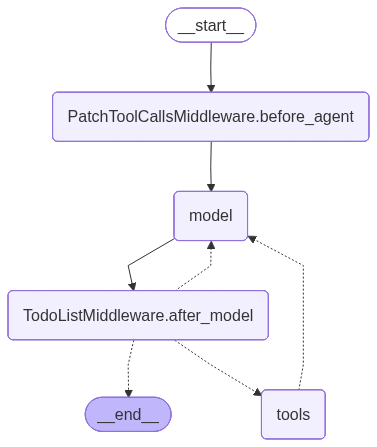

In [31]:
print("\n" + "="*65)
print("EXPERIMENT 2: Scope 업그레이드 — Layer 2 권한 획득")
print("="*65)

diana_r2 = AuthContext("diana_r2", "analyst_restricted")

print("\n[Step 1] analyst_restricted — Layer 2 read:internal 없음 (부분 실패 예상)")
agent = run_test(diana_r2, Q_ANALYSIS)

print("\n[OTP 플로우]")
print("  POST /agent/auth/claim          -> OTP 이메일 발송")
print("  POST /agent/auth/claim/complete -> 검증 완료")
diana_r2.upgrade_scope("read:internal", reason="OTP claim confirmed")

print("\n[Step 2] 동일 agent 재시도 — Layer 2 통과 예상")
run_test(diana_r2, Q_ANALYSIS, agent=agent)

---
## Part 5: Pass Rate 측정

Two-Layer 구조에서 각 레이어별 통과율을 별도로 측정한다.

| 지표 | 정의 |
|------|------|
| Layer 1 Pass Rate | 접근 가능한 skill 수 / 전체 skill 수 (auth.md skill 스코프 기반) |
| Layer 2 Pass Rate | skill 실행 시 tool 스코프가 충족되는 비율 (내부 tool 스코프 기반) |
| End-to-End Pass Rate | Layer 1 + Layer 2 모두 통과한 쿼리 비율 |
| Partial Fail Rate | Layer 1 통과 but Layer 2 부분 차단된 비율 (두 레이어 구조에서만 발생) |

In [32]:
@dataclass
class TwoLayerTracker:
    role: str
    # Layer 1
    l1_attempts:  dict = field(default_factory=lambda: defaultdict(int))
    l1_successes: dict = field(default_factory=lambda: defaultdict(int))
    # Layer 2
    l2_attempts:  dict = field(default_factory=lambda: defaultdict(int))
    l2_successes: dict = field(default_factory=lambda: defaultdict(int))
    # Query
    query_results: list = field(default_factory=list)

    def record_l1(self, skill_name: str, passed: bool):
        self.l1_attempts[skill_name] += 1
        if passed:
            self.l1_successes[skill_name] += 1

    def record_l2(self, tool_scope: str, passed: bool):
        self.l2_attempts[tool_scope] += 1
        if passed:
            self.l2_successes[tool_scope] += 1

    def record_query(self, name: str, response: str):
        tool_denied = "[TOOL DENIED]" in response
        self.query_results.append({
            "name": name,
            "e2e_pass": not tool_denied,
            "partial_fail": tool_denied,
        })

    # ── (passed, total) 튜플 반환 → M/N 표시용 ──────────────
    @property
    def l1_counts(self) -> tuple:
        m = sum(self.l1_successes.values())
        n = sum(self.l1_attempts.values())
        return m, n

    @property
    def l2_counts(self) -> tuple:
        m = sum(self.l2_successes.values())
        n = sum(self.l2_attempts.values())
        return m, n

    @property
    def e2e_counts(self) -> tuple:
        m = sum(1 for r in self.query_results if r["e2e_pass"])
        return m, len(self.query_results)

    @property
    def partial_counts(self) -> tuple:
        m = sum(1 for r in self.query_results if r["partial_fail"])
        return m, len(self.query_results)

    # ── 비율 ──────────────────────────────────────────────────
    @property
    def l1_pass_rate(self) -> float:
        m, n = self.l1_counts
        return m / n if n > 0 else 0.0

    @property
    def l2_pass_rate(self) -> float:
        m, n = self.l2_counts
        return m / n if n > 0 else 0.0

    @property
    def e2e_pass_rate(self) -> float:
        m, n = self.e2e_counts
        return m / n if n > 0 else 0.0

    @property
    def partial_fail_rate(self) -> float:
        m, n = self.partial_counts
        return m / n if n > 0 else 0.0


# ─── 계측용 build_skill_tool ────────────────────────────────
def build_tracked_skill_tool(
    skill_name: str, skill_info: dict,
    auth_ctx: AuthContext, tracker: TwoLayerTracker
) -> StructuredTool:
    required_tool_scopes = skill_info["internal_tool_scopes"]
    description = skill_info["description"]

    def skill_executor(request: str) -> str:
        steps = []
        denied = []
        for scope in required_tool_scopes:
            passed = auth_ctx.can_use_tool(scope)
            tracker.record_l2(scope, passed)
            if not passed:
                denied.append(scope)
                steps.append(f"  [TOOL DENIED] '{scope}'")
            else:
                result = TOOL_REGISTRY[scope]["fn"](
                    **{arg: request for arg in TOOL_REGISTRY[scope]["args"]}
                )
                steps.append(f"  [OK] {scope}: {result[:60]}")
        status = "완료" if not denied else f"부분 실패 (차단: {denied})"
        return f"[{skill_name}] {status}\n" + "\n".join(steps)

    return StructuredTool.from_function(
        func=skill_executor, name=skill_name, description=description
    )

print("계측 인프라 준비 완료")

계측 인프라 준비 완료


In [33]:
# ─── 테스트 매트릭스 ──────────────────────────────────────────
TEST_MATRIX = [
    {"name": "리서치",      "query": "LangChain v1.0 변경사항 리서치해줘.",         "required_skill": "skill:research",      "required_tools": ["read:external"]},
    {"name": "데이터분석",   "query": "sales 데이터셋을 분석해줘.",                  "required_skill": "skill:data_analysis", "required_tools": ["read:internal", "read:external"]},
    {"name": "알림발송",     "query": "개발팀에게 배포 완료 알림을 보내줘.",           "required_skill": "skill:notification",  "required_tools": ["write:external"]},
    {"name": "통합리포트",   "query": "이번 달 성과 리포트를 생성하고 팀에게 배포해줘.", "required_skill": "skill:reporting",     "required_tools": ["read:internal", "read:external", "write:external"]},
    {"name": "코드리뷰",     "query": "main.py를 코드 리뷰해줘.",                    "required_skill": "skill:code_review",   "required_tools": ["read:internal"]},
]

ROLES_TO_TEST = ["admin", "analyst", "analyst_restricted", "developer", "viewer", "guest"]
print(f"테스트: {len(ROLES_TO_TEST)}개 역할 x {len(TEST_MATRIX)}개 쿼리")
for tc in TEST_MATRIX:
    print(f"  {tc['name']:12s} | L1: {tc['required_skill']:25s} | L2: {tc['required_tools']}")

테스트: 6개 역할 x 5개 쿼리
  리서치          | L1: skill:research            | L2: ['read:external']
  데이터분석        | L1: skill:data_analysis       | L2: ['read:internal', 'read:external']
  알림발송         | L1: skill:notification        | L2: ['write:external']
  통합리포트        | L1: skill:reporting           | L2: ['read:internal', 'read:external', 'write:external']
  코드리뷰         | L1: skill:code_review         | L2: ['read:internal']


In [34]:
# ─── Static Pass Rate (계산 기반) ────────────────────────────
print("\n" + "="*75)
print("PASS RATE — Two-Layer Auth (계산 기반, API 호출 없음)")
print("="*75)

static_results = {}

for role in ROLES_TO_TEST:
    ctx = AuthContext(f"pr_{role}", role)

    total = len(TEST_MATRIX)

    # L1: skill 스코프 통과 수 / 전체 쿼리 수
    l1_passed = sum(1 for tc in TEST_MATRIX if ctx.can_access_skill(tc["required_skill"]))
    l1_rate = l1_passed / total

    # E2E: L1 + L2 모두 통과한 수 / 전체 쿼리 수
    e2e_passed = sum(
        1 for tc in TEST_MATRIX
        if ctx.can_access_skill(tc["required_skill"])
        and all(ctx.can_use_tool(s) for s in tc["required_tools"])
    )
    e2e_rate = e2e_passed / total

    # L2: L1 통과 쿼리 중 tool 스코프도 충족한 비율 (분모 = l1_passed)
    l2_rate = e2e_passed / l1_passed if l1_passed > 0 else 0.0

    # 부분 실패: L1 통과 but L2 차단
    partial_fail = l1_passed - e2e_passed
    partial_rate = partial_fail / total

    static_results[role] = {
        "total": total,
        "l1_rate": l1_rate, "l1_passed": l1_passed,
        "l2_rate": l2_rate, "l2_passed": e2e_passed, "l2_total": l1_passed,
        "e2e_rate": e2e_rate, "e2e_passed": e2e_passed,
        "partial_rate": partial_rate, "partial_fail": partial_fail,
    }

col = [20, 16, 16, 16, 18]
sep = "+" + "+".join("-"*w for w in col) + "+"
def row_s(*v): return "|" + "|".join(f" {str(x):{col[i]-2}s} " for i, x in enumerate(v)) + "|"

print(sep)
print(row_s("역할", "L1 통과율(skill)", "L2 통과율(tool)", "E2E 통과율", "부분실패율(L1ok/L2fail)"))
print(sep)
for role in ROLES_TO_TEST:
    r = static_results[role]
    print(row_s(
        role,
        f"{r['l1_rate']:.0%} ({r['l1_passed']}/{r['total']})",
        f"{r['l2_rate']:.0%} ({r['l2_passed']}/{r['l2_total'] or '-'})",
        f"{r['e2e_rate']:.0%} ({r['e2e_passed']}/{r['total']})",
        f"{r['partial_rate']:.0%} ({r['partial_fail']}/{r['total']})",
    ))
print(sep)
print("\n* 부분실패 = Layer 1(skill 접근) 통과 but Layer 2(tool 실행) 차단 — Two-Layer 구조에서만 발생")


PASS RATE — Two-Layer Auth (계산 기반, API 호출 없음)
+--------------------+----------------+----------------+----------------+------------------+
| 역할                 | L1 통과율(skill)  | L2 통과율(tool)   | E2E 통과율        | 부분실패율(L1ok/L2fail) |
+--------------------+----------------+----------------+----------------+------------------+
| admin              | 100% (5/5)     | 100% (5/5)     | 100% (5/5)     | 0% (0/5)         |
| analyst            | 60% (3/5)      | 67% (2/3)      | 40% (2/5)      | 20% (1/5)        |
| analyst_restricted | 60% (3/5)      | 33% (1/3)      | 20% (1/5)      | 40% (2/5)        |
| developer          | 60% (3/5)      | 100% (3/3)     | 60% (3/5)      | 0% (0/5)         |
| viewer             | 20% (1/5)      | 100% (1/1)     | 20% (1/5)      | 0% (0/5)         |
| guest              | 0% (0/5)       | 0% (0/-)       | 0% (0/5)       | 0% (0/5)         |
+--------------------+----------------+----------------+----------------+------------------+

* 부분실패 = Layer 1(ski

In [35]:
# ─── Dynamic Pass Rate (실행 기반, 샘플 3쿼리) ───────────────
SAMPLED = TEST_MATRIX[:3]  # 리서치, 데이터분석, 알림발송

print("\n" + "="*75)
print("PASS RATE — Two-Layer Auth (실행 기반)")
print(f"  대상: {len(ROLES_TO_TEST)}개 역할 x {len(SAMPLED)}개 샘플 쿼리")
print("="*75)

dynamic_results = {}

for role in ROLES_TO_TEST:
    ctx = AuthContext(f"pr_{role}", role)
    tracker = TwoLayerTracker(role=role)
    accessible = get_accessible_skills(ctx)

    if not accessible:
        for tc in SAMPLED:
            tracker.query_results.append({"name": tc["name"], "e2e_pass": False, "partial_fail": False})
        dynamic_results[role] = tracker
        continue

    # Layer 1 기록
    for name in SKILLS_MD["skills"]:
        tracker.record_l1(name, name in accessible)

    tracked_tools = [
        build_tracked_skill_tool(name, info, ctx, tracker)
        for name, info in accessible.items()
    ]
    agent = create_deep_agent(model=MODEL, tools=tracked_tools)

    for tc in SAMPLED:
        result = agent.invoke({"messages": [{"role": "user", "content": tc["query"]}]})
        response = result["messages"][-1].content
        tracker.record_query(tc["name"], response)

    dynamic_results[role] = tracker
    l1_m, l1_n = tracker.l1_counts
    l2_m, l2_n = tracker.l2_counts
    e2e_m, e2e_n = tracker.e2e_counts
    pf_m, pf_n = tracker.partial_counts
    print(
        f"  {role:20s} | "
        f"L1: {tracker.l1_pass_rate:.0%}({l1_m}/{l1_n}개skill) | "
        f"L2: {tracker.l2_pass_rate:.0%}({l2_m}/{l2_n}개tool) | "
        f"E2E: {tracker.e2e_pass_rate:.0%}({e2e_m}/{e2e_n}개쿼리) | "
        f"부분실패: {tracker.partial_fail_rate:.0%}({pf_m}/{pf_n})"
    )


PASS RATE — Two-Layer Auth (실행 기반)
  대상: 6개 역할 x 3개 샘플 쿼리
  admin                | L1: 100%(5/5개skill) | L2: 100%(3/3개tool) | E2E: 100%(3/3개쿼리) | 부분실패: 0%(0/3)
  analyst              | L1: 60%(3/5개skill) | L2: 100%(1/1개tool) | E2E: 100%(3/3개쿼리) | 부분실패: 0%(0/3)
  analyst_restricted   | L1: 60%(3/5개skill) | L2: 100%(1/1개tool) | E2E: 100%(3/3개쿼리) | 부분실패: 0%(0/3)
  developer            | L1: 60%(3/5개skill) | L2: 100%(2/2개tool) | E2E: 100%(3/3개쿼리) | 부분실패: 0%(0/3)
  viewer               | L1: 20%(1/5개skill) | L2: 100%(1/1개tool) | E2E: 100%(3/3개쿼리) | 부분실패: 0%(0/3)


In [36]:
# ─── 최종 비교표 ─────────────────────────────────────────────
print("\n" + "="*82)
print("최종 Pass Rate 비교 (계산 기반 vs 실행 기반)")
print("="*82)

col2 = [20, 18, 18, 18, 18, 18]
sep2 = "+" + "+".join("-"*w for w in col2) + "+"
def row2(*v): return "|" + "|".join(f" {str(x):{col2[i]-2}s} " for i, x in enumerate(v)) + "|"

print(sep2)
print(row2("역할", "S:L1 M/N(skill)", "S:L2 M/N(tool)", "S:E2E M/N", "D:E2E M/N", "D:부분실패 M/N"))
print(sep2)

for role in ROLES_TO_TEST:
    s = static_results[role]
    d = dynamic_results[role]
    e2e_m, e2e_n = d.e2e_counts
    pf_m, pf_n = d.partial_counts
    print(row2(
        role,
        f"{s['l1_rate']:.0%} ({s['l1_passed']}/{s['total']})",
        f"{s['l2_rate']:.0%} ({s['l2_passed']}/{s['l2_total'] or '-'})",
        f"{s['e2e_rate']:.0%} ({s['e2e_passed']}/{s['total']})",
        f"{d.e2e_pass_rate:.0%} ({e2e_m}/{e2e_n})",
        f"{d.partial_fail_rate:.0%} ({pf_m}/{pf_n})",
    ))
print(sep2)
print()
print("S=계산기반  D=실행기반  L1=skill접근  L2=tool실행  E2E=전체통과  부분실패=L1ok+L2fail")

# 부분 실패 역할 강조
print("\n[주목] analyst_restricted 부분 실패 상세:")
d = dynamic_results.get("analyst_restricted")
if d:
    for r in d.query_results:
        status = "E2E 성공" if r["e2e_pass"] else ("부분 실패(L1ok/L2fail)" if r["partial_fail"] else "L1 차단")
        print(f"  {r['name']:12s} | {status}")


최종 Pass Rate 비교 (계산 기반 vs 실행 기반)
+--------------------+------------------+------------------+------------------+------------------+------------------+
| 역할                 | S:L1 M/N(skill)  | S:L2 M/N(tool)   | S:E2E M/N        | D:E2E M/N        | D:부분실패 M/N       |
+--------------------+------------------+------------------+------------------+------------------+------------------+
| admin              | 100% (5/5)       | 100% (5/5)       | 100% (5/5)       | 100% (3/3)       | 0% (0/3)         |
| analyst            | 60% (3/5)        | 67% (2/3)        | 40% (2/5)        | 100% (3/3)       | 0% (0/3)         |
| analyst_restricted | 60% (3/5)        | 33% (1/3)        | 20% (1/5)        | 100% (3/3)       | 0% (0/3)         |
| developer          | 60% (3/5)        | 100% (3/3)       | 60% (3/5)        | 100% (3/3)       | 0% (0/3)         |
| viewer             | 20% (1/5)        | 100% (1/1)       | 20% (1/5)        | 100% (3/3)       | 0% (0/3)         |
| guest              |

---
## 시각화

In [38]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# macOS 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지


/var/folders/72/r3bhmsld13l6rpb21_v62g6w0000gn/T/ipykernel_54229/3128424886.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(roles, rotation=20, ha="right", fontsize=8)


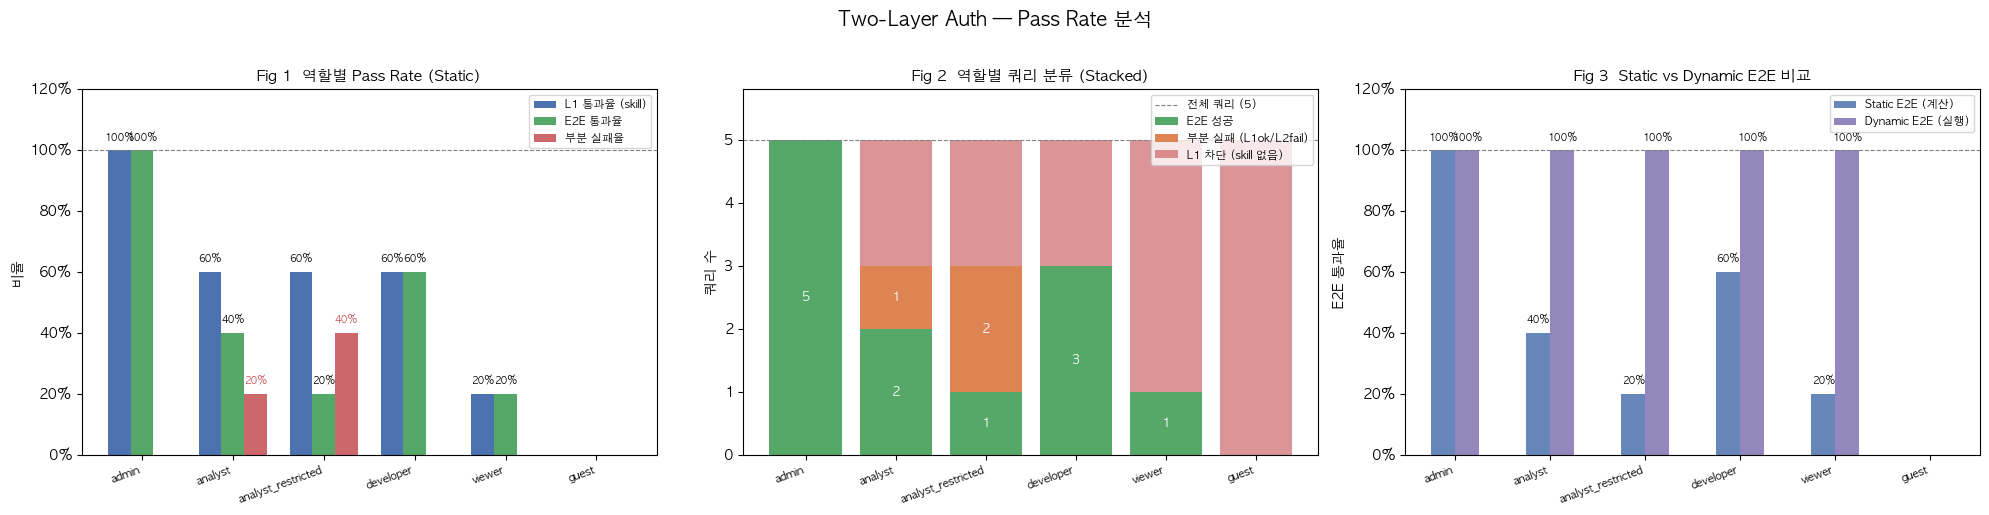

저장 완료: pass_rate_analysis.png


In [39]:
# ─── Pass Rate 시각화 (3 figures) ────────────────────────────
roles = ROLES_TO_TEST
total = len(TEST_MATRIX)

l1_rates  = [static_results[r]["l1_rate"]   for r in roles]
e2e_rates = [static_results[r]["e2e_rate"]  for r in roles]
pf_rates  = [static_results[r]["partial_rate"] for r in roles]
l2_rates  = [static_results[r]["l2_rate"]   for r in roles]

e2e_counts = [static_results[r]["e2e_passed"]  for r in roles]
pf_counts  = [static_results[r]["partial_fail"] for r in roles]
l1_blocked = [total - static_results[r]["l1_passed"] for r in roles]

d_e2e_rates = [dynamic_results[r].e2e_pass_rate for r in roles]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Two-Layer Auth — Pass Rate 분석", fontsize=14, fontweight="bold", y=1.02)

x = np.arange(len(roles))
w = 0.25
COLORS = {"l1": "#4C72B0", "e2e": "#55A868", "pf": "#C44E52",
          "dyn": "#8172B2", "blk": "#DD8452"}

# ── Fig 1: 역할별 L1 / E2E / 부분실패율 Grouped Bar ────────────
ax = axes[0]
ax.bar(x - w, l1_rates,  width=w, label="L1 통과율 (skill)", color=COLORS["l1"])
ax.bar(x,     e2e_rates, width=w, label="E2E 통과율",        color=COLORS["e2e"])
ax.bar(x + w, pf_rates,  width=w, label="부분 실패율",        color=COLORS["pf"], alpha=0.85)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Fig 1  역할별 Pass Rate (Static)", fontsize=11)
ax.set_ylabel("비율"); ax.set_ylim(0, 1.2)
ax.set_xticks(x); ax.set_xticklabels(roles, rotation=20, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(fontsize=8, loc="upper right")
for i, (l1, e2e, pf) in enumerate(zip(l1_rates, e2e_rates, pf_rates)):
    if l1 > 0:  ax.text(i - w, l1  + 0.03, f"{l1:.0%}",  ha="center", fontsize=7)
    if e2e > 0: ax.text(i,     e2e + 0.03, f"{e2e:.0%}", ha="center", fontsize=7)
    if pf > 0:  ax.text(i + w, pf  + 0.03, f"{pf:.0%}",  ha="center", fontsize=7, color=COLORS["pf"])

# ── Fig 2: 역할별 쿼리 분류 Stacked Bar ───────────────────────
ax = axes[1]
b1 = ax.bar(roles, e2e_counts, label="E2E 성공",             color=COLORS["e2e"])
b2 = ax.bar(roles, pf_counts,  bottom=e2e_counts,             label="부분 실패 (L1ok/L2fail)", color=COLORS["blk"])
b3 = ax.bar(roles, l1_blocked, bottom=[e+p for e,p in zip(e2e_counts, pf_counts)],
            label="L1 차단 (skill 없음)", color=COLORS["pf"], alpha=0.6)
ax.axhline(total, color="gray", linestyle="--", linewidth=0.8, label=f"전체 쿼리 ({total})")
ax.set_title("Fig 2  역할별 쿼리 분류 (Stacked)", fontsize=11)
ax.set_ylabel("쿼리 수"); ax.set_ylim(0, total + 0.8)
ax.set_xticklabels(roles, rotation=20, ha="right", fontsize=8)
ax.legend(fontsize=8, loc="upper right")
ax.set_yticks(range(total + 1))
for bar in b1:
    h = bar.get_height()
    if h > 0: ax.text(bar.get_x() + bar.get_width()/2, h/2, str(int(h)),
                      ha="center", va="center", fontsize=9, color="white", fontweight="bold")
for bar, base in zip(b2, e2e_counts):
    h = bar.get_height()
    if h > 0: ax.text(bar.get_x() + bar.get_width()/2, base + h/2, str(int(h)),
                      ha="center", va="center", fontsize=9, color="white", fontweight="bold")

# ── Fig 3: Static vs Dynamic E2E 비교 ─────────────────────────
ax = axes[2]
ax.bar(x - w/2, e2e_rates,   width=w, label="Static E2E (계산)",  color=COLORS["l1"], alpha=0.85)
ax.bar(x + w/2, d_e2e_rates, width=w, label="Dynamic E2E (실행)", color=COLORS["dyn"], alpha=0.85)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Fig 3  Static vs Dynamic E2E 비교", fontsize=11)
ax.set_ylabel("E2E 통과율"); ax.set_ylim(0, 1.2)
ax.set_xticks(x); ax.set_xticklabels(roles, rotation=20, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(fontsize=8)
for i, (s, d) in enumerate(zip(e2e_rates, d_e2e_rates)):
    if s > 0: ax.text(i - w/2, s + 0.03, f"{s:.0%}", ha="center", fontsize=7)
    if d > 0: ax.text(i + w/2, d + 0.03, f"{d:.0%}", ha="center", fontsize=7)

plt.tight_layout()
plt.savefig("pass_rate_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장 완료: pass_rate_analysis.png")

---
## 결론

### Two-Layer Auth의 핵심 발견

1. **`analyst_restricted` 케이스가 두 레이어 구조의 가치를 증명**한다:
   - Layer 1(skill 접근): `skill:data_analysis` 보유 → skills.md 접근 허용
   - Layer 2(tool 실행): `read:internal` 없음 → DB 조회 차단
   - 결과: 스킬은 실행되지만 내부적으로 부분 실패 → **"부분 실패율"** 이라는 새 지표가 생김

2. **단일 레이어(tool 실험)에서는 관찰할 수 없는 케이스**:
   - Tool 실험: tool 접근 차단 = 완전 실패 (0 or 1)
   - Skill 실험: skill 접근 허용 + tool 차단 = 부분 실패 (0.x)

3. **auth.md는 단일 권한 소스로 두 레이어를 모두 제어**한다:
   - `skill:*` 스코프 → Layer 1 게이팅
   - `read:*/write:*` 스코프 → Layer 2 게이팅
   - skills.md는 별도 권한 시스템이 아닌 auth.md 스코프에 의존하는 레지스트리

### 권장 아키텍처

```
사용자 → auth.md 인증 (단일 소스)
              │
              ├─ skill:* 스코프 → skills.md 접근 게이팅 (Layer 1)
              │       ↓
              │   접근 허용된 Skill Layer 실행
              │       ↓
              └─ read:*/write:* 스코프 → Tool Layer 게이팅 (Layer 2)
```

### Pass Rate 지표 해석
- `L1 Pass Rate` = 사용자가 실행 요청할 수 있는 workflow 비율
- `L2 Pass Rate` = L1 통과한 workflow 중 실제 완전 실행 가능한 비율
- `Partial Fail Rate` = 권한 구성 오류 탐지 지표 (0이 아니면 auth.md role 설계 검토 필요)